In [2]:
""" Genuine multipartite entanglement / correlations for 3-qubit MIXED states. 
=========================================================================

Two measures that (i) work for mixed states, (ii) need N= 3-tangle convex roof, and (iii) are maximixed by the GHZ state


1) -- Genuine Multipartite Negativity (Jungnitsc, Moroder, Guehne,
PRL 106, 190502 (2011)). A proper genuine multipartite entanglement 
monotone: it is ZERO for every biseparable state (pure or mixed,
including mixures of different bipartitions), and positive ONLY when 
the state is genuinely tripartite entangled. Computed by a single 
semidefinnite program (SDP) -- no convex roof. Max over 3 quibits is 
the GHZ state, GMN(GHZ) = 1/2.   


2) pi - tangle residual 3-partite entanglement built from NEGATIVITIES 
 (Ou & Fan, PRA 75, 062308 (2007)). Fully computable for mixed 
 computable cousin of the 3-tangle and is maximized by GHZ
 (pi(GHZ)=1). NOTE: it is a residual entanglement quantifier, not a 
 strict GME monotone, so it can be > 0 for some biseparable state. 
 Use it as a fast GHZ-oriented figure of merit; use GMN when you.
  need a rigorous "genuine" certificate. 
   

"""

import numpy as np
import cvxpy as cp


# ------------------------------------------------------------------
# Basic linear - algebra helpers (pure numpy)
# ------------------------------------------------------------------

def partial_transpose(rho, dims, sys):
    """
    Partial transpose of density matrix rho over subsystem index sys. 
    """
    n = len(dims)
    d = int(np.prod(dims))
    r = rho.reshape(dims + dims)
    exes = list(range(2*n))
    exes[sys], exes[n+sys] = exes[n+sys], exes[sys]
    return r.transpose(exes).reshape(d, d)


def partial_trace(rho, dims, keep):
    """
     Partial trace of `rho` keeping the subsystems listed in `keep`  
    """
    n    = len(dims)
    keep = sorted(keep)
    r    = rho.reshape(dims + dims)
    trace_out = [i for i in range(n) if i not in keep]
    for t in sorted(trace_out, reverse=True):
        r = np.trace(r,axis1=t, axis2=t + (r.ndim//2))
    d_keep = int(np.prod([dims[i] for i in keep]))
    return r.reshape(d_keep, d_keep) 


def negativity(rho, dims, sys):
    """Negativity N = ||rho^{T_sys}||_1 - 1  (Bell/GHZ bipartition -> 1)."""
    pt = partial_transpose(rho, dims, sys)
    pt = (pt +pt.conj().T)/2.0   # symmetrize to avoid numerical issues
    ev = np.linalg.eigvalsh(pt)
    return float(np.sum(np.abs(ev)) - 1.0) 
    
    
# ------------------------------------------------------------------
#1) Genuine Multipartite Negativity (GMN) via SDP
#------------------------------------------------------------------

def genuine_multipartite_negativity(rho,solver=None):
    """ 
    GMN for a 3-qubit density matrix `rho` (8x8, trace 1).    
    Canonical PPT-mixer witness SDP (Jungnitsch-Moroder-Guehne):      
    minimize   Tr(W rho)        subject to for each bipartition m:  W = P_m + Q_m^{T_m},        
    P_m >= 0,   0 <= Q_m <= I   
    and returns  GMN = -min Tr(W rho)   ( >= 0 ; 0 iff biseparable/PPT-mixture ).   
    Normalization: GMN(GHZ) = 1/2,  GMN(W) = sqrt(2)/3 ~ 0.4714.  GHZ is the   
    maximizer over all 3-qubit states.    """
    
    dims = [2, 2, 2]
    d = 8
    rho = np.asarray(rho, dtype= complex)
    
    W = cp.Variable((d,d), hermitian=True)
    constraints = []
    for m in range(3):  # bipartitions A|BC, B|AC, C|AB
         P = cp.Variable((d, d), hermitian=True)        
         Q = cp.Variable((d, d), hermitian=True)
         constraints += [P >> 0, Q >> 0, np.eye(d) - Q >> 0,
                         W == P + cp.partial_transpose(Q, dims, m)]       
    prob = cp.Problem(cp.Minimize(cp.real(cp.trace(W @ rho))), constraints)
     # CLARABEL is default; fall back to SCS (higher precision) if needed.  
    order = [solver] if solver else [cp.CLARABEL, cp.SCS]
    val = None
    for s in order:
        try:
             prob.solve(solver=s)
             if prob.value is not None:
                  val = prob.value
                  if prob.status == cp.OPTIMAL:
                       break
        except cp.error.SolverError:
             continue
    if val is None:
               raise RuntimeError("SDP did not solve; install another solver (e.g. MOSEK).")
    return max(0.0, -val)
                      
    


# ------------------------------------------------------------------
# 2) pi- tangle (negativity-based residual 3-tangle) 
#-------------------------------------------------------------------

def pi_tangle(rho):
     """Ou-Fan pi-tangle for a 3-qubit density matrix. pi(GHZ)=1."""
     dims = [2,2,2]
     rho = np.asarray(rho, dtype= complex)
     
     # one-vs-rest negativities
     N_A = negativity(rho, dims, 0) # A|BC
     N_B = negativity(rho, dims, 1) # B|AC
     N_C = negativity(rho, dims, 2) # C|AB
     
     # two-qubit reduced negativities
     rho_AB = partial_trace(rho, dims, keep=[0, 1])
     rho_AC = partial_trace(rho, dims, keep=[0, 2])
     rho_BC = partial_trace(rho, dims, keep=[1, 2])
     
     N_AB = negativity(rho_AB, [2, 2], 0)
     N_AC = negativity(rho_AC, [2, 2], 0)
     N_BC = negativity(rho_BC, [2, 2], 0)
     
     pi_A = N_A ** 2 - N_AB ** 2 - N_AC ** 2
     pi_B = N_B ** 2 - N_AB ** 2 - N_BC ** 2
     pi_C = N_C ** 2 - N_AC ** 2 - N_BC ** 2
     
     return (pi_A + pi_B + pi_C) / 3.0
 
 
 #--------------------------------------------------------
 # Demo / self-tests
#----------------------------------------------------------

def _ket(bits):
    V = np.zeros(8, dtype=complex)
    V[int(bits,2)] = 1.0
    return V

if __name__ == "__main__":
    # GHZ state
    ghz = (_ket("000") + _ket("111")) / np.sqrt(2)
    rho_ghz = np.outer(ghz, ghz.conj())
    
    # W
    w = (_ket("001") + _ket("010") + _ket("100")) / np.sqrt(3)
    rho_w = np.outer(w, w.conj())
    
    
    # fully separable product |+>|+>|+>? use |000>
    rho_prod = np.outer(_ket("000"), _ket("000").conj())
    
    
    # biseparable mixed: (Bell on AB)⊗|0>_C  mixed with (Bell on AC)⊗|0>_B
    bell_ab = (_ket("000") + _ket("110")) / np.sqrt(2)
    bell_ac = (_ket("000") + _ket("101")) / np.sqrt(2)
    r_ab = np.outer(bell_ab, bell_ab.conj())
    r_ac = np.outer(bell_ac, bell_ac.conj())
    rho_bisep = 0.5 * r_ab + 0.5 * r_ac
    
    # GHZ + white noise:  p |GHZ><GHZ| + (1-p) I/8
    def ghz_noisy(p):
        return p * rho_ghz + (1 - p) * np.eye(8) / 8
    
    print("state            GMN        pi-tangle")
    print("-" * 42)
    for name, r in [("GHZ", rho_ghz), ("W", rho_w),
                    ("product |000>", rho_prod),
                    ("biseparable mix", rho_bisep)]:
        print(f"{name:16s} {genuine_multipartite_negativity(r):8.4f}   {pi_tangle(r):8.4f}")
    print("\nGHZ + white noise  (genuinely entangled iff p > 3/7 = 0.4286):")
    for p in [0.3, 3/7, 0.5, 0.7, 1.0]:
        r = ghz_noisy(p)
        print(f"  p={p:5.3f}   GMN={genuine_multipartite_negativity(r):8.4f} pi= {pi_tangle(r):7.4f}")
    
    
        
                    
    
      
     
     

state            GMN        pi-tangle
------------------------------------------
GHZ                0.5000     1.0000


c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\cvxpy\problems\problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


W                  0.4712     0.5494
product |000>      0.0000     0.0000
biseparable mix    0.0000     0.2060

GHZ + white noise  (genuinely entangled iff p > 3/7 = 0.4286):
  p=0.300   GMN=  0.0000 pi=  0.0156
  p=0.429   GMN=  0.0000 pi=  0.0816
  p=0.500   GMN=  0.0625 pi=  0.1406
  p=0.700   GMN=  0.2375 pi=  0.3906
  p=1.000   GMN=  0.5000 pi=  1.0000


In [1]:
from gme_3qubits import genuine_multipartite_negativity,pi_tangle
from qiskit.quantum_info import Statevector, partial_trace, DensityMatrix,negativity,state_fidelity,Operator,concurrence,entropy,purity
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke


from qiskit_dynamics import Solver

from qiskit import pulse
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import numpy as np
import sympy as sym

import jax
jax.config.update("jax_enable_x64", True)

In [4]:
backend = FakeSherbrooke()

#configuracion de backend
propiedades = backend.properties()
configuracion = backend.configuration()


Hz = 1e9
# Definicion de la frecuencia de los qubits en GHz
w7   = configuracion.hamiltonian.get("vars").get("wq7")
w8   = configuracion.hamiltonian.get("vars").get("wq8")
w9   = configuracion.hamiltonian.get("vars").get("wq9")
# anamornicidad de los qubits en GHz
delta7 = configuracion.hamiltonian.get("vars").get("delta7")
delta8 = configuracion.hamiltonian.get("vars").get("delta8")
delta9 = configuracion.hamiltonian.get("vars").get("delta9")
# acoples en GHz
J78 = configuracion.hamiltonian.get("vars").get("jq7q8")
J89 = configuracion.hamiltonian.get("vars").get("jq8q9")
# fuerza de control en GHz
r0   =  configuracion.hamiltonian.get("vars").get("omegad7")
r1   =  configuracion.hamiltonian.get("vars").get("omegad8")
r2   =  configuracion.hamiltonian.get("vars").get("omegad9")
# tiempo de gate en ns
dt = backend.dt*1e9

# tiempo de relajación y decoherencia en segundos
T1_7 = propiedades.qubit_property(7,'T1')[0]  # tiempo de relajación
T2_7 = propiedades.qubit_property(7,'T2')[0]  # tiempo de decoherencia
T1_8 = propiedades.qubit_property(8,'T1')[0]  # tiempo de relajación
T2_8 = propiedades.qubit_property(8,'T2')[0]  # tiempo de decoherencia
T1_9 = propiedades.qubit_property(9,'T1')[0]  # tiempo de relajación    
T2_9 = propiedades.qubit_property(9,'T2')[0]  # tiempo de decoherencia  


v7 = w7/(2*np.pi)  # frecuencia en GHz
v8 = w8/(2*np.pi)  # frecuencia en GHz
v9 = w9/(2*np.pi)  # frecuencia en GHz  


Hz = 1e9
# Definicion de la frecuencia de los qubits en GHz
w7   = configuracion.hamiltonian.get("vars").get("wq7")
w8   = configuracion.hamiltonian.get("vars").get("wq8")
w9   = configuracion.hamiltonian.get("vars").get("wq9")
# anamornicidad de los qubits en GHz
delta7 = configuracion.hamiltonian.get("vars").get("delta7")
delta8 = configuracion.hamiltonian.get("vars").get("delta8")
delta9 = configuracion.hamiltonian.get("vars").get("delta9")
# acoples en GHz
J78 = configuracion.hamiltonian.get("vars").get("jq7q8")
J89 = configuracion.hamiltonian.get("vars").get("jq8q9")
# fuerza de control en GHz
r0   =  configuracion.hamiltonian.get("vars").get("omegad7")
r1   =  configuracion.hamiltonian.get("vars").get("omegad8")
r2   =  configuracion.hamiltonian.get("vars").get("omegad9")
# tiempo de gate en ns
dt = backend.dt*1e9


v7 = w7 /(2*np.pi)
v8 = w8 /(2*np.pi)
v9 = w9 /(2*np.pi)

# Definir los operadores 
dim = 2
a = np.diag(np.sqrt(np.arange(1, dim)), 1)
adag = np.diag(np.sqrt(np.arange(1, dim)), -1)
N = np.diag(np.arange(dim))

ident = np.eye(dim, dtype=complex)
full_ident = np.eye(dim**3, dtype=complex)

N0 = np.kron(ident,np.kron(ident, N))
N1 = np.kron(ident,np.kron(N, ident))
N2 = np.kron(np.kron(N, ident),ident)

a0 = np.kron(ident,np.kron(ident, a))
a1 = np.kron(ident,np.kron(a, ident))
a2 = np.kron(np.kron(a, ident),ident)


a0dag = np.kron(ident,np.kron(ident, adag))
a1dag = np.kron(ident,np.kron(adag, ident))
a2dag = np.kron(np.kron(adag, ident),ident)

# Haniltoniano del sistema
static_ham = 2*np.pi*v7 * N0  +2*np.pi*v8 * N1  + 2*np.pi*v9* N2   + J78*(a0dag @ a1 +  a0 @ a1dag) + J89*(a1dag @ a2 +  a1 @ a2dag)

# Hamiltonianos de controles
H_drive7 =  r0 * (a0 + a0dag)
H_drive8 =  r1 * (a1 + a1dag)
H_drive9 =  r2 * (a2 + a2dag)
  

# Tiempos T1 y T2 en ns
T1_7 = T1_7*1e9
T2_7 = T2_7*1e9
T1_8 = T1_8*1e9
T2_8 = T2_8*1e9
T1_9 = T1_9*1e9
T2_9 = T2_9*1e9
# gammas de relajación y decoherencia
gamma1_7 = 1/T1_7
gamma2_7 = 1/T2_7 - 1/(2*T1_7)
gamma1_8 = 1/T1_8
gamma2_8 = 1/T2_8 - 1/(2*T1_8)
gamma1_9 = 1/T1_9
gamma2_9 = 1/T2_9 - 1/(2*T1_9)


Z0  = full_ident - 2*N0
Z1  = full_ident - 2*N1
Z2  = full_ident - 2*N2

sm1 = a0
sm2 = a1
sm3 = a2

sz1 = Z0
sz2 = Z1 
sZ3 = Z2

collapse_operators = [np.sqrt(gamma1_7)*a0,
                      np.sqrt(gamma1_8)*a1,
                      np.sqrt(gamma1_9)*a2,
                      np.sqrt(gamma2_7)*Z0,
                      np.sqrt(gamma2_8)*Z1,
                      np.sqrt(gamma2_9)*Z2]

In [5]:
print(r0,r1,r2)

0.39575797919595557 0.6501466069370565 0.3148551427122911


In [6]:
from qiskit import pulse

def esque_pul(params):
    t_0, t_1, t_2,t_3,A0, A1, A2, A3, A4,  = params

    # Convertir a enteros por requerimiento del backend
    t_0 = int(t_0)
    t_1 = int(t_1)
    t_2 = int(t_2)
    t_3 = int(t_3)
    

    with pulse.build(name="pulso 3q") as kp:
        d0 = pulse.DriveChannel(0)
        d1 = pulse.DriveChannel(1)
        d2 = pulse.DriveChannel(2)
        u0 = pulse.ControlChannel(0)
        u1 = pulse.ControlChannel(1)

        # Primer pulso en d0 y d1
        pulse.play(pulse.Constant(duration=t_0, amp=A0), d0)
        pulse.play(pulse.Constant(duration=t_0, amp=A1), d1)
        
    
        # Delay en canal u0
        pulse.delay(duration=t_0 + 1, channel=u0)
        
        # Segundo pulso en d1 y u0
        pulse.play(pulse.Constant(duration=t_1 , amp=A2), u0)
        
       # delay pulso d2 y u1 
        pulse.delay(duration= (t_0+ t_1 + 1 ), channel= d2)
        pulse.delay(duration= (t_0+ t_1 + t_2 +1  ), channel= u1)
        
        
        # pulsos locales d1 y d2 
        pulse.play(pulse.Constant(duration=t_2, amp=A3),d2)
        # pulse.play(pulse.Constant(duration=t_2, amp=A4),d1)
        
       # pulso local d2
        # pulse.play(pulse.Constant(duration=t_3, amp=A4),d2)
        
        
      # pulso u1
        pulse.play(pulse.Constant(duration=t_3, amp=A4),u1)
        
    return kp

In [7]:
solver = Solver(static_hamiltonian=static_ham,
                hamiltonian_operators=[H_drive7, H_drive8, H_drive9, H_drive7, H_drive8],
                static_dissipators = collapse_operators,
                dissipator_channels= None,
                hamiltonian_channels= ["d0", "d1", "d2", "u0", "u1"],
                channel_carrier_freqs= {"d0": v7, "d1": v8, "d2": v9, "u0": v8, "u1": v9},
                dt=dt,
                array_library='jax'
                )





rho_0 = DensityMatrix.from_label('000')

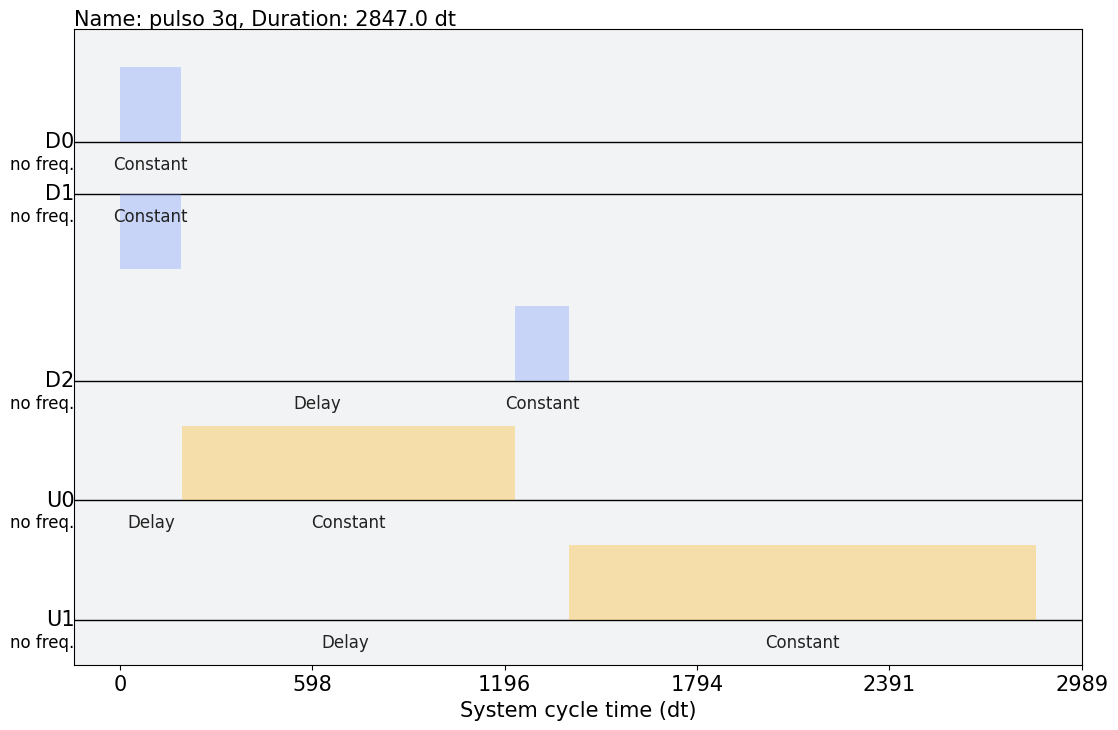

In [8]:
X_GHZ =  [
    1.91779586e+02, 1.03750354e+03, 1.68736170e+02, 1.45046248e+03,
    4.90394435e-01, -6.91612520e-01, 6.65492967e-01, 1.65200193e-01,
    6.19735822e-01
]

esque_pul(X_GHZ).draw()

In [9]:
def evol_GHZ_lindblab(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=rho_0,
        signals=signal,
        # method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    # yf = sol.y[-1]
    
    return sol

In [10]:
matrix_GHZ = evol_GHZ_lindblab(X_GHZ)

In [11]:
len(matrix_GHZ.y)

43635

In [12]:
import numpy as np
from qiskit.quantum_info import DensityMatrix

def sanitize_density_matrix(rho):
    """
    Corrige una matriz para que sea una matriz densidad física:
    - Hermítica
    - Traza 1
    - Semidefinida positiva
    """
    rho = np.array(rho, dtype=complex)

    # 1) Forzar hermiticidad
    rho = 0.5 * (rho + rho.conj().T)

    # 2) Diagonalizar
    eigvals, eigvecs = np.linalg.eigh(rho)

    # 3) Eliminar negativos pequeños
    eigvals[eigvals < 0] = 0

    # 4) Reconstruir
    rho = eigvecs @ np.diag(eigvals) @ eigvecs.conj().T

    # 5) Renormalizar traza
    rho = rho / np.trace(rho)

    return DensityMatrix(rho)

In [13]:
genuine_multipartite_negativity(matrix_GHZ.y[-1])

c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\cvxpy\problems\problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


0.43608773996751127

In [ ]:
len(matrix_GHZ.y)

In [51]:
# Lista del 0 al 20, con un espacio de 5 en 5
numeros_enteros = list(range(0,43636 , 700
                             ))
print(numeros_enteros)
print(len(numeros_enteros))


[0, 700, 1400, 2100, 2800, 3500, 4200, 4900, 5600, 6300, 7000, 7700, 8400, 9100, 9800, 10500, 11200, 11900, 12600, 13300, 14000, 14700, 15400, 16100, 16800, 17500, 18200, 18900, 19600, 20300, 21000, 21700, 22400, 23100, 23800, 24500, 25200, 25900, 26600, 27300, 28000, 28700, 29400, 30100, 30800, 31500, 32200, 32900, 33600, 34300, 35000, 35700, 36400, 37100, 37800, 38500, 39200, 39900, 40600, 41300, 42000, 42700, 43400]
63


In [38]:
g_m_n = []
time_GHZ_open = []
for k in numeros_enteros:
    g_m_n.append(genuine_multipartite_negativity(matrix_GHZ.y[k].data))
    time_GHZ_open.append(matrix_GHZ.t[k])
    print(genuine_multipartite_negativity(matrix_GHZ.y[k]))

0.0
0.007636614912498169
0.014540270172466788
0.002549092686980759


c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\cvxpy\problems\problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


0.001593306684551328
0.002094986552683609
0.002683406642364327
0.0026240423691825682
0.001598007517309966
0.00342669133023704
0.0038646845478157326
0.002160206345451385
0.005492486845654193
0.0032829116198267636
0.005579709174371488
0.005664654391218493
0.005099272080208582
0.007645864242870932
0.00689162812595469
0.005730152691544106
0.0055001897279155654
0.005689457788503324
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
0.23130992540330608
0.24834882096922103
0.2654994371678677
0.28188373259817645
0.2977706979290108
0.3127705300504988
0.32705874595504725
0.3405475435690697
0.3532086249097539
0.3650196053535498
0.37597523328739957
0.38606009063098434
0.39528091446377456
0.4035847297773413
0.4109948167275056
0.41749310071377455
0.42303742842614916
0.4276606438668916
0.4313442794882148
0.43405682657730316
0.4358246551435643
0.4366829042359961
0.4364442571058303


In [31]:
import gc
gc.collect()

0

In [63]:
for  indice, valor  in enumerate(g_m_n):
    print(indice,    valor, numeros_enteros[indice], sep=" | " )

0 | 0.0 | 0
1 | 0.007636614912498169 | 700
2 | 0.014540270172466788 | 1400
3 | 0.002549092686980759 | 2100
4 | 0.001593306684551328 | 2800
5 | 0.002094986552683609 | 3500
6 | 0.002683406642364327 | 4200
7 | 0.0026240423691825682 | 4900
8 | 0.001598007517309966 | 5600
9 | 0.00342669133023704 | 6300
10 | 0.0038646845478157326 | 7000
11 | 0.002160206345451385 | 7700
12 | 0.005492486845654193 | 8400
13 | 0.0032829116198267636 | 9100
14 | 0.005579709174371488 | 9800
15 | 0.005664654391218493 | 10500
16 | 0.005099272080208582 | 11200
17 | 0.007645864242870932 | 11900
18 | 0.00689162812595469 | 12600
19 | 0.005730152691544106 | 13300
20 | 0.0055001897279155654 | 14000
21 | 0.005689457788503324 | 14700
22 | inf | 15400
23 | inf | 16100
24 | inf | 16800
25 | inf | 17500
26 | inf | 18200
27 | inf | 18900
28 | inf | 19600
29 | inf | 20300
30 | inf | 21000
31 | inf | 21700
32 | 0.23130992540330608 | 22400
33 | 0.24834882096922103 | 23100
34 | 0.2654994371678677 | 23800
35 | 0.28188373259817645 | 2

In [74]:
lista_nueva = [15400,16100,16800,17500,18200,18900,19600,20300,21000,21700]

new_gmn = []
for l in lista_nueva:
    new_gmn.append(genuine_multipartite_negativity(sanitize_density_matrix(matrix_GHZ.y[l].data)))
    print(genuine_multipartite_negativity(sanitize_density_matrix(matrix_GHZ.y[l].data)))

0.0023741442057747635
0.0030768170606332423
0.0049569494851567945
0.019440141525777544
0.038899405190406106
0.05814719575769669
0.07766816842888263
0.09682631096956254
0.11562781802945823
0.1342511605073169


In [84]:
g_m_n[22:32] = new_gmn


In [85]:
g_m_n

[0.0,
 0.007636614912498169,
 0.014540270172466788,
 0.002549092686980759,
 0.001593306684551328,
 0.002094986552683609,
 0.002683406642364327,
 0.0026240423691825682,
 0.001598007517309966,
 0.00342669133023704,
 0.0038646845478157326,
 0.002160206345451385,
 0.005492486845654193,
 0.0032829116198267636,
 0.005579709174371488,
 0.005664654391218493,
 0.005099272080208582,
 0.007645864242870932,
 0.00689162812595469,
 0.005730152691544106,
 0.0055001897279155654,
 0.005689457788503324,
 0.0023741442057747635,
 0.0030768170606332423,
 0.0049569494851567945,
 0.019440141525777544,
 0.038899405190406106,
 0.05814719575769669,
 0.07766816842888263,
 0.09682631096956254,
 0.11562781802945823,
 0.1342511605073169,
 0.23130992540330608,
 0.24834882096922103,
 0.2654994371678677,
 0.28188373259817645,
 0.2977706979290108,
 0.3127705300504988,
 0.32705874595504725,
 0.3405475435690697,
 0.3532086249097539,
 0.3650196053535498,
 0.37597523328739957,
 0.38606009063098434,
 0.39528091446377456,
 0

In [ ]:
g_m_n = [0.0,
 0.007636614912498169,
 0.014540270172466788,
 0.002549092686980759,
 0.001593306684551328,
 0.002094986552683609,
 0.002683406642364327,
 0.0026240423691825682,
 0.001598007517309966,
 0.00342669133023704,
 0.0038646845478157326,
 0.002160206345451385,
 0.005492486845654193,
 0.0032829116198267636,
 0.005579709174371488,
 0.005664654391218493,
 0.005099272080208582,
 0.007645864242870932,
 0.00689162812595469,
 0.005730152691544106,
 0.0055001897279155654,
 0.005689457788503324,
 0.0023741442057747635,
 0.0030768170606332423,
 0.0049569494851567945,
 0.019440141525777544,
 0.038899405190406106,
 0.05814719575769669,
 0.07766816842888263,
 0.09682631096956254,
 0.11562781802945823,
 0.1342511605073169,
 0.23130992540330608,
 0.24834882096922103,
 0.2654994371678677,
 0.28188373259817645,
 0.2977706979290108,
 0.3127705300504988,
 0.32705874595504725,
 0.3405475435690697,
 0.3532086249097539,
 0.3650196053535498,
 0.37597523328739957,
 0.38606009063098434,
 0.39528091446377456,
 0.4035847297773413,
 0.4109948167275056,
 0.41749310071377455,
 0.42303742842614916,
 0.4276606438668916,
 0.4313442794882148,
 0.43405682657730316,
 0.4358246551435643,
 0.4366829042359961,
 0.4364442571058303]

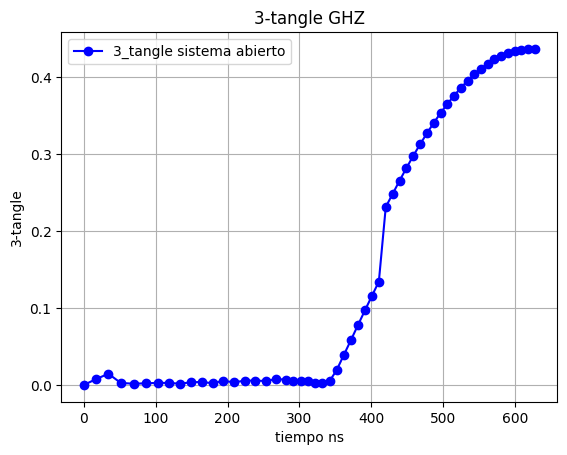

In [86]:
# 2. Crear el gráfico
plt.plot(time_GHZ_open, g_m_n, marker='o', linestyle='-', color='b', label='3_tangle sistema abierto')

# 3. Personalizar (opcional)
plt.title("genuine_multipartite_negativity")
plt.xlabel("tiempo ns")
plt.ylabel("3-tangle")
plt.legend()
plt.grid(True)

# 4. Mostrar el gráfico
plt.show()

In [16]:
solver = Solver(
    static_hamiltonian=static_ham,
    hamiltonian_operators=[H_drive7, H_drive8, H_drive9, H_drive7, H_drive8],
    hamiltonian_channels=["d0", "d1", "d2", "u0", "u1"],
    channel_carrier_freqs= {"d0": v7, "d1": v8, "d2": v9, "u0": v8, "u1": v9},
    dt=dt,
    array_library="jax",
)

In [ ]:
y0  = Statevector.from_label("000")
def evo_GHZ(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        # method="jax_odeint",
        atol=1e-8,
        rtol=1e-8
    )
    # yf = sol.y[-1]/np.linalg.norm(sol.y[-1])
    return sol

In [18]:
SV_T = evo_GHZ(X_GHZ)

In [19]:
len(SV_T.y)

65404

In [29]:
genuine_multipartite_negativity(DensityMatrix(SV_T.y[65100]).data)

0.49979924904037387

In [28]:
# Lista del 0 al 20, con un espacio de 5 en 5
numeros_enteros = list(range(0,65404 , 700
                             ))
print(numeros_enteros)
print(len(numeros_enteros))


[0, 700, 1400, 2100, 2800, 3500, 4200, 4900, 5600, 6300, 7000, 7700, 8400, 9100, 9800, 10500, 11200, 11900, 12600, 13300, 14000, 14700, 15400, 16100, 16800, 17500, 18200, 18900, 19600, 20300, 21000, 21700, 22400, 23100, 23800, 24500, 25200, 25900, 26600, 27300, 28000, 28700, 29400, 30100, 30800, 31500, 32200, 32900, 33600, 34300, 35000, 35700, 36400, 37100, 37800, 38500, 39200, 39900, 40600, 41300, 42000, 42700, 43400, 44100, 44800, 45500, 46200, 46900, 47600, 48300, 49000, 49700, 50400, 51100, 51800, 52500, 53200, 53900, 54600, 55300, 56000, 56700, 57400, 58100, 58800, 59500, 60200, 60900, 61600, 62300, 63000, 63700, 64400, 65100]
94


In [35]:
g_m_n_close = []
time_GHZ_close = []
for k in numeros_enteros:
    g_m_n_close.append(genuine_multipartite_negativity(sanitize_density_matrix(DensityMatrix(SV_T.y[k]).data)))
    time_GHZ_close.append(SV_T.t[k])
    print(genuine_multipartite_negativity(sanitize_density_matrix(DensityMatrix( SV_T.y[k]).data)))

0.0


c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\cvxpy\problems\problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


0.009867509328671156
0.009334993670330045
0.0018147420390327348
0.011036541967244858
0.0028632224289695846
0.0026122161143284943
0.0024522458050335386
0.002250428455547593
0.0030106543356055535
0.003267717420337451
0.002486447522867297
0.0040830573324590735
0.0038827115275127553
0.003526263840546876
0.005610306498413716
0.0034886449023908105
0.006314177857818038
0.0048851892914040405
0.006517562583018228
0.0061798189724215895
0.006878435523544253
0.006884403292821228
0.007376053920043396
0.007553775152782603
0.007861727359735657
0.008499529507897082
0.008416764126253523
0.009261779061085839
0.00922545958874551
0.009392704537131109
0.010877447457287016
0.009468227166345055
0.007913735359145722
0.006897220526000098
0.0064039177480249
0.006701392071736496
0.014676683267976647
0.027612535197322832
0.04112916292734813
0.05477036531187504
0.06836396363586376
0.08192071741604087
0.0954372732980818
0.10888073978068202
0.12224083661673874
0.13550566514768433
0.14866758445472267
0.16173589488128

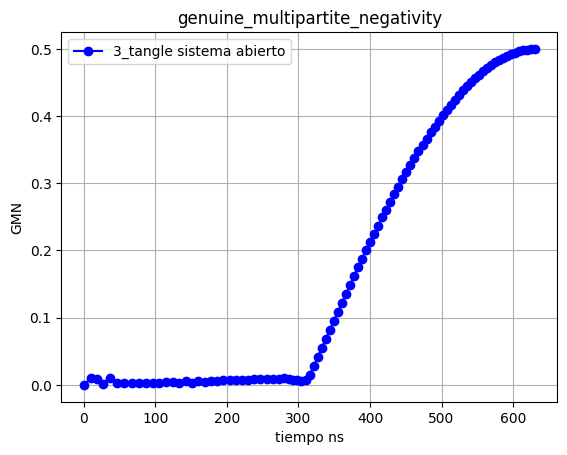

In [36]:
# 2. Crear el gráfico
plt.plot(time_GHZ_close, g_m_n_close, marker='o', linestyle='-', color='b', label='3_tangle sistema abierto')

# 3. Personalizar (opcional)
plt.title("genuine_multipartite_negativity")
plt.xlabel("tiempo ns")
plt.ylabel("GMN")
plt.legend()
plt.grid(True)

# 4. Mostrar el gráfico
plt.show()

In [17]:
time_GHZ_close = [np.float64(0.0),
 np.float64(9.346032225302318),
 np.float64(18.111616384481838),
 np.float64(26.578831471996057),
 np.float64(36.52160347982276),
 np.float64(46.11824978410953),
 np.float64(56.536503935815624),
 np.float64(66.88121275026411),
 np.float64(76.79410220715731),
 np.float64(86.49268311070081),
 np.float64(96.06571312447346),
 np.float64(105.46383792745307),
 np.float64(114.79533362154046),
 np.float64(123.96561214117874),
 np.float64(133.07459956391915),
 np.float64(142.16257472760418),
 np.float64(151.06618440657186),
 np.float64(160.0182627846965),
 np.float64(168.8989820990587),
 np.float64(177.64168349326772),
 np.float64(186.488741255995),
 np.float64(195.16489037327975),
 np.float64(203.85755039096014),
 np.float64(212.58116427677774),
 np.float64(221.11480379610327),
 np.float64(229.79474150516933),
 np.float64(238.3418603123709),
 np.float64(246.86885015534597),
 np.float64(255.4786762878403),
 np.float64(263.88553460711694),
 np.float64(272.4557406707059),
 np.float64(279.8459907293095),
 np.float64(286.2832730420888),
 np.float64(292.38361844515117),
 np.float64(298.3084194983482),
 np.float64(304.1237048212195),
 np.float64(309.8653896688955),
 np.float64(315.4847742211976),
 np.float64(321.1670979754533),
 np.float64(326.84515323981367),
 np.float64(332.5185471912711),
 np.float64(338.1881495860952),
 np.float64(343.8537230063528),
 np.float64(349.51494311495856),
 np.float64(355.17280900541294),
 np.float64(360.82717094593113),
 np.float64(366.47770677770086),
 np.float64(372.12548139232126),
 np.float64(377.7703330307746),
 np.float64(383.41191501346174),
 np.float64(389.0512430792142),
 np.float64(394.6880928903906),
 np.float64(400.3220797966799),
 np.float64(405.95413004470754),
 np.float64(411.58394820891795),
 np.float64(417.2111460565514),
 np.float64(422.83659336051966),
 np.float64(428.4599310659106),
 np.float64(434.0808189197103),
 np.float64(439.70014134501815),
 np.float64(445.31749988200437),
 np.float64(450.9326365085752),
 np.float64(456.5464817417647),
 np.float64(462.15859449669483),
 np.float64(467.7688069393135),
 np.float64(473.37808021086204),
 np.float64(478.98591729442484),
 np.float64(484.5922308572566),
 np.float64(490.197971399307),
 np.float64(495.8025773012673),
 np.float64(501.4060301071005),
 np.float64(507.0092266218994),
 np.float64(512.6115386355738),
 np.float64(518.2130168258522),
 np.float64(523.8144835062409),
 np.float64(529.4152516898986),
 np.float64(535.015454608799),
 np.float64(540.6158391368269),
 np.float64(546.2156733509634),
 np.float64(551.8151937167926),
 np.float64(557.4150815756083),
 np.float64(563.0145756293568),
 np.float64(568.6140314279445),
 np.float64(574.214070464905),
 np.float64(579.8139159952227),
 np.float64(585.4140427942532),
 np.float64(591.0150067085375),
 np.float64(596.6160262630438),
 np.float64(602.2176780861002),
 np.float64(607.8204392237299),
 np.float64(613.4235315145824),
 np.float64(619.0276072202157),
 np.float64(624.6330510860163),
 np.float64(630.2390942627383)]

In [16]:
g_m_n_close = [0.0,
0.009867509328671156,
0.009334993670330045,
0.0018147420390327348,
0.011036541967244858,
0.0028632224289695846,
0.0026122161143284943,
0.0024522458050335386,
0.002250428455547593,
0.0030106543356055535,
0.003267717420337451,
0.002486447522867297,
0.0040830573324590735,
0.0038827115275127553,
0.003526263840546876,
0.005610306498413716,
0.0034886449023908105,
0.006314177857818038,
0.0048851892914040405,
0.006517562583018228,
0.0061798189724215895,
0.006878435523544253,
0.006884403292821228,
0.007376053920043396,
0.007553775152782603,
0.007861727359735657,
0.008499529507897082,
0.008416764126253523,
0.009261779061085839,
0.00922545958874551,
0.009392704537131109,
0.010877447457287016,
0.009468227166345055,
0.007913735359145722,
0.006897220526000098,
0.0064039177480249,
0.006701392071736496,
0.014676683267976647,
0.027612535197322832,
0.04112916292734813,
0.05477036531187504,
0.06836396363586376,
0.08192071741604087,
0.0954372732980818,
0.10888073978068202,
0.12224083661673874,
0.13550566514768433,
0.14866758445472267,
0.16173589488128617,
0.17467301760164652,
0.18745126947835133,
0.20010534191750678,
0.21262184216889846,
0.22494378276269242,
0.2371203467090814,
0.2491065427224755,
0.2608843822540653,
0.27246891758080405,
0.2838571648541019,
0.2950130852072139,
0.3059370435585742,
0.31663911282545465,
0.32710049770726074,
0.3373021260331044,
0.347260114391156,
0.3569523567258931,
0.36638077731930796,
0.37552026503974556,
0.3843906028010368,
0.3929787929190022,
0.40126087732958865,
0.4092469388764791,
0.4169378827871042,
0.4243087267081197,
0.4313580204452844,
0.43809933279974433,
0.4445071600342244,
0.4505755326491341,
0.45631717471638866,
0.46171862947390474,
0.46676862757920407,
0.47147242010545604,
0.47582924533352045,
0.479828553821649,
0.483468023152957,
0.4867518348547671,
0.4896732793570701,
0.49222734134308754,
0.4944163211347379,
0.49623928713171483,
0.4976894652457242,
0.4987714094470447,
0.49948889430810717,
0.499817593718214]

In [9]:
data = np.load("GHZ_open.npz")

time = data["time"]
GMN = data["GMN"]


In [11]:
GMN

array([0.        , 0.00292688, 0.00229213, 0.00196734, 0.0016085 ,
       0.00167553, 0.00225433, 0.00182561, 0.00270382, 0.00311684,
       0.00203526, 0.00430468, 0.00434684, 0.00259639, 0.00439318,
       0.00627655, 0.0056239 , 0.00352744, 0.00457098, 0.00756361,
       0.00797959, 0.00709902, 0.00237414, 0.00307682, 0.00495695,
       0.01944014, 0.03889941, 0.0581472 , 0.07766817, 0.09682631,
       0.11562782, 0.13425116, 0.15237729, 0.17021016, 0.18759726,
       0.20453804, 0.22105108, 0.2370547 , 0.25257518, 0.26756895,
       0.28188373, 0.29583171, 0.3090589 , 0.32177327, 0.33388747,
       0.34536757, 0.35621992, 0.36642315, 0.37597523, 0.3848549 ,
       0.39306589, 0.40058015, 0.40745076, 0.41356026, 0.41895856,
       0.42368152, 0.42766064, 0.43093784, 0.43347065, 0.43529542,
       0.43636879, 0.43674598, 0.43636066])

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
C:\Users\PC\AppData\Local\Temp\ipykernel_8608\2970821290.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Time $\mu$s")


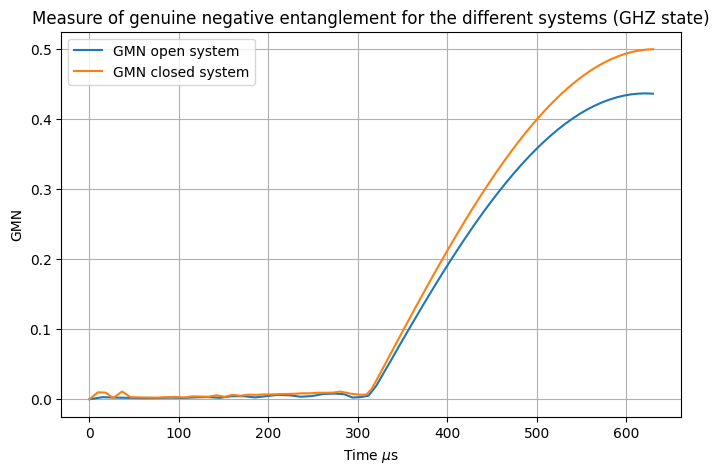

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(time, GMN, label="GMN open system")
plt.plot(time_GHZ_close, g_m_n_close, label="GMN closed system")
plt.title("Measure of genuine negative entanglement for the different systems (GHZ state)")
plt.xlabel("Time $\mu$s")
plt.ylabel("GMN")
plt.legend()
plt.grid(True)

plt.show()